# 03 · The theory forward model

The differentiable JAX halo model that maps the five gas parameters to the 42-vector, plus
the two validations that matter: the **resolved** power spectra (1-halo / 2-halo split,
restricted to the mass range the catalog actually resolves) and the **projected paste
operator** against the spherical theory it is meant to reproduce.

`three_probe_jax_forward_model.py` · `three_probe_resolved_theory.py` ·
`three_probe_projected_operator.py` · `build_three_probe_reference_point.py`

In [1]:
import json, pathlib, sys
import numpy as np, h5py
import matplotlib.pyplot as plt
ROOT = pathlib.Path("/mnt/ceph/users/spandey/ltu-godmax/GODMAX")
sys.path.insert(0, str(ROOT / "notebooks/SBI_validate/common"))
DATA = ROOT / "data/SBI_validate"
VAL  = DATA / "three_probe_mock/validation"
INF  = DATA / "three_probe_inference"
MSBI = DATA / "mock_sbi"
BLUE, ORANGE, GREEN, INK2, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#52514e", "#dedcd6"
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.edgecolor": GRID, "xtick.color": INK2, "ytick.color": INK2,
                     "font.size": 10.5, "axes.spines.top": False, "axes.spines.right": False})
SPECTRA = ["gy", "gkappa", "gtau"]
LBL = {"gg": r"$g \times g$", "gy": r"$g \times y$",
       "gkappa": r"$g \times \kappa_{\rm CMB}$", "gtau": r"$g \times \tau$"}

### Resolved P(k): the 1-halo / 2-halo split for each probe

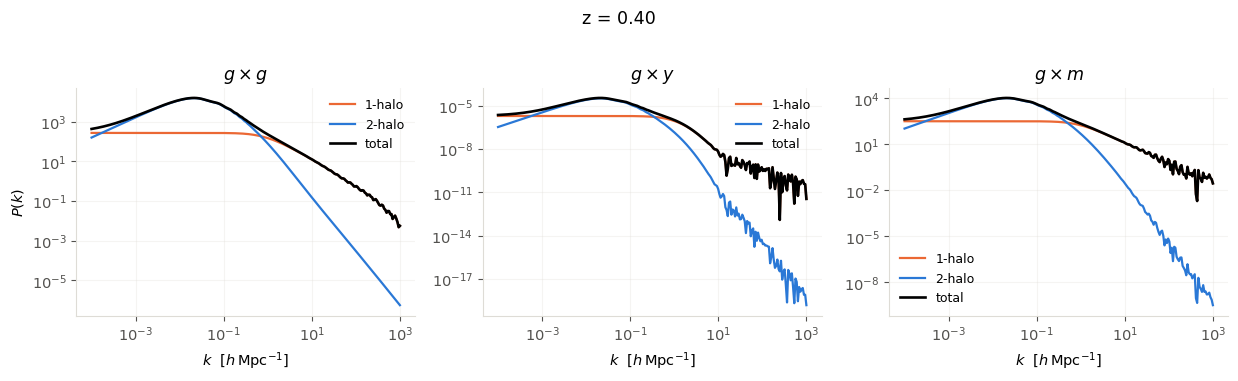

In [2]:
d = np.load(VAL / "resolved_theory/resolved_power_components.npz")
k = np.asarray(d["k_hmpc"], float); z = np.asarray(d["redshift"], float)
iz = int(np.argmin(np.abs(z - 0.4)))
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.7))
for ax, p, t in zip(axes, ["Pgg", "Pgy", "Pgm"], [LBL["gg"], LBL["gy"], r"$g \times m$"]):
    ax.loglog(k, np.abs(d[f"{p}_1h"][:, iz]), color=ORANGE, lw=1.6, label="1-halo")
    ax.loglog(k, np.abs(d[f"{p}_2h"][:, iz]), color=BLUE,   lw=1.6, label="2-halo")
    ax.loglog(k, np.abs(d[f"{p}_resolved"][:, iz]), color="k", lw=1.9, label="total")
    ax.set_title(t); ax.set_xlabel(r"$k$  [$h\,$Mpc$^{-1}$]"); ax.grid(alpha=.3, color=GRID)
    ax.legend(frameon=False, fontsize=9)
axes[0].set_ylabel(r"$P(k)$")
fig.suptitle(f"z = {z[iz]:.2f}", y=1.02); fig.tight_layout()

### The projected paste operator against spherical theory

The paste paints a *projected* profile on the sphere. This is the ratio of that operator to
the spherical calculation it approximates — the closer to 1, the less the paste geometry
biases the pasted maps.

median |ratio - 1| over all mass/z/k: 0.0350


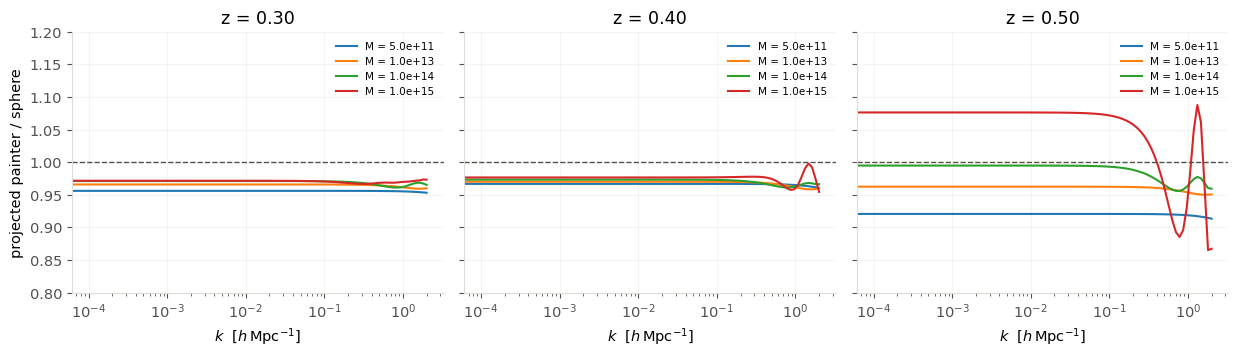

In [3]:
o = np.load(VAL / "projected_operator/projected_operator_baseline.npz", allow_pickle=True)
kk = np.asarray(o["k_hmpc"], float)
sph, coshp = np.asarray(o["sphere"], float), np.asarray(o["painter_cosh"], float)
M, Z = np.asarray(o["actual_mass_hmsun"], float), np.asarray(o["actual_redshift"], float)
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.7), sharey=True)
for i, ax in enumerate(axes):
    for j in range(sph.shape[2]):
        good = np.abs(sph[i, i, j]) > 0
        ax.semilogx(kk[good], (coshp[i, i, j] / sph[i, i, j])[good], lw=1.5,
                    label=f"M = {M[i, j]:.1e}")
    ax.axhline(1.0, color=INK2, lw=1.0, ls="--"); ax.set_ylim(0.8, 1.2)
    ax.set_xlabel(r"$k$  [$h\,$Mpc$^{-1}$]"); ax.grid(alpha=.3, color=GRID)
    ax.set_title(f"z = {Z[i, 0]:.2f}"); ax.legend(frameon=False, fontsize=7.5)
axes[0].set_ylabel("projected painter / sphere"); fig.tight_layout()
r = coshp / np.where(sph == 0, np.nan, sph)
print("median |ratio - 1| over all mass/z/k:", f"{np.nanmedian(np.abs(r - 1)):.4f}")

### The pinned reference point the samplers start from

In [4]:
ref = np.load(MSBI / "oracle_sc_reference_point.npz", allow_pickle=True)
print("u_map           ", np.asarray(ref["u_map"], float).round(4))
print("score operator  ", np.asarray(ref["operator"]).shape)
print("posterior metric", np.asarray(ref["posterior_metric"]).shape)
H = np.asarray(ref["posterior_metric"], float)
print("metric eigenvalues", np.linalg.eigvalsh(H).round(3))

u_map            [-0.9485 -0.3792 -0.1588 -0.2159 -0.015 ]
score operator   (5, 42)
posterior metric (5, 5)
metric eigenvalues [1.0030000e+00 1.1580000e+00 8.4050000e+00 1.5192800e+02 1.0910535e+05]
